# Credit Risk Model
## Notebook 3: Modeling — XGBoost, LightGBM, SMOTE & Evaluation

**Goal:** Train baseline → XGBoost → LightGBM → Ensemble  
Optimize threshold for business cost, evaluate with ROC-AUC, F1, Recall  
**Input:** data/X_features.csv, data/y_target.csv  
**Output:** Trained models + all evaluation plots saved to reports/

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    f1_score, recall_score, precision_score,
    precision_recall_curve, average_precision_score
)
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTEENN
import xgboost as xgb
import lightgbm as lgb

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("All imports successful.")
print(f"XGBoost: {xgb.__version__}  |  LightGBM: {lgb.__version__}")

All imports successful.
XGBoost: 3.2.0  |  LightGBM: 4.6.0


In [3]:
X = pd.read_csv('../data/X_features.csv')
y = pd.read_csv('../data/y_target.csv').squeeze()

# Clean any inf/nan that slipped through
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(X.median(), inplace=True)

print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"Default rate: {y.mean():.2%}")
print(f"\nSample features: {list(X.columns[:8])}")

X shape : (307511, 27)
y shape : (307511,)
Default rate: 8.07%

Sample features: ['EXT_SOURCE_MEAN', 'EXT_SOURCE_PROD', 'EXT_SOURCE_MIN', 'EXT_SOURCE_3', 'EXT_SOURCE_2', 'CREDIT_TERM', 'DAYS_EMPLOYED', 'EMPLOYED_YEARS']


In [4]:
# ── ALWAYS split before SMOTE — this is the #1 interview trap ──
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("BEFORE SMOTE:")
print(f"  Train: {X_train.shape}  |  Default rate: {y_train.mean():.2%}")
print(f"  Test : {X_test.shape}   |  Default rate: {y_test.mean():.2%}")

# Apply SMOTE only on training data
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("\nAFTER SMOTE (training only):")
print(f"  Train: {X_train_sm.shape}")
print(f"  Class 0: {(y_train_sm==0).sum():,}  |  Class 1: {(y_train_sm==1).sum():,}")
print(f"  Test unchanged: {X_test.shape}  ← test set is NEVER touched")

BEFORE SMOTE:
  Train: (246008, 27)  |  Default rate: 8.07%
  Test : (61503, 27)   |  Default rate: 8.07%

AFTER SMOTE (training only):
  Train: (452296, 27)
  Class 0: 226,148  |  Class 1: 226,148
  Test unchanged: (61503, 27)  ← test set is NEVER touched


In [5]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_sm)
X_test_sc  = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train_sc, y_train_sm)

lr_proba = lr.predict_proba(X_test_sc)[:, 1]
lr_pred  = lr.predict(X_test_sc)

print("BASELINE — Logistic Regression")
print("=" * 45)
print(f"  ROC-AUC  : {roc_auc_score(y_test, lr_proba):.4f}")
print(f"  F1 Score : {f1_score(y_test, lr_pred):.4f}")
print(f"  Recall   : {recall_score(y_test, lr_pred):.4f}")
print(f"  Precision: {precision_score(y_test, lr_pred):.4f}")
print("=" * 45)
print("\n(We expect XGBoost to significantly beat this)")

BASELINE — Logistic Regression
  ROC-AUC  : 0.7262
  F1 Score : 0.2473
  Recall   : 0.6387
  Precision: 0.1533

(We expect XGBoost to significantly beat this)


In [6]:
imbalance_ratio = int((y_train_sm == 0).sum() / (y_train_sm == 1).sum())

xgb_model = xgb.XGBClassifier(
    n_estimators      = 300,
    max_depth         = 5,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    min_child_weight  = 5,
    gamma             = 0.1,
    reg_alpha         = 0.1,
    reg_lambda        = 1.0,
    scale_pos_weight  = imbalance_ratio,
    eval_metric       = 'auc',
    random_state      = 42,
    n_jobs            = -1
)

xgb_model.fit(
    X_train_sm, y_train_sm,
    eval_set=[(X_test, y_test)],
    verbose=50
)

xgb_proba = xgb_model.predict_proba(X_test)[:, 1]
xgb_pred  = xgb_model.predict(X_test)

print("\nXGBoost Results:")
print("=" * 45)
print(f"  ROC-AUC  : {roc_auc_score(y_test, xgb_proba):.4f}")
print(f"  F1 Score : {f1_score(y_test, xgb_pred):.4f}")
print(f"  Recall   : {recall_score(y_test, xgb_pred):.4f}")
print(f"  Precision: {precision_score(y_test, xgb_pred):.4f}")
print("=" * 45)

[0]	validation_0-auc:0.61431
[50]	validation_0-auc:0.67822
[100]	validation_0-auc:0.68850
[150]	validation_0-auc:0.69410
[200]	validation_0-auc:0.69748
[250]	validation_0-auc:0.70089
[299]	validation_0-auc:0.70352

XGBoost Results:
  ROC-AUC  : 0.7035
  F1 Score : 0.1865
  Recall   : 0.1605
  Precision: 0.2226


In [7]:
lgb_model = lgb.LGBMClassifier(
    n_estimators      = 300,
    max_depth         = 5,
    learning_rate     = 0.05,
    num_leaves        = 31,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    min_child_samples = 20,
    reg_alpha         = 0.1,
    reg_lambda        = 1.0,
    class_weight      = 'balanced',
    random_state      = 42,
    n_jobs            = -1,
    verbose           = -1
)

lgb_model.fit(
    X_train_sm, y_train_sm,
    eval_set=[(X_test, y_test)]
)

lgb_proba = lgb_model.predict_proba(X_test)[:, 1]
lgb_pred  = lgb_model.predict(X_test)

print("LightGBM Results:")
print("=" * 45)
print(f"  ROC-AUC  : {roc_auc_score(y_test, lgb_proba):.4f}")
print(f"  F1 Score : {f1_score(y_test, lgb_pred):.4f}")
print(f"  Recall   : {recall_score(y_test, lgb_pred):.4f}")
print(f"  Precision: {precision_score(y_test, lgb_pred):.4f}")
print("=" * 45)

LightGBM Results:
  ROC-AUC  : 0.7051
  F1 Score : 0.1700
  Recall   : 0.1307
  Precision: 0.2432


ENSEMBLE (XGB 50% + LGB 50%):
  ROC-AUC  : 0.7051
  F1 Score : 0.1766
  Recall   : 0.1424
  Precision: 0.2323


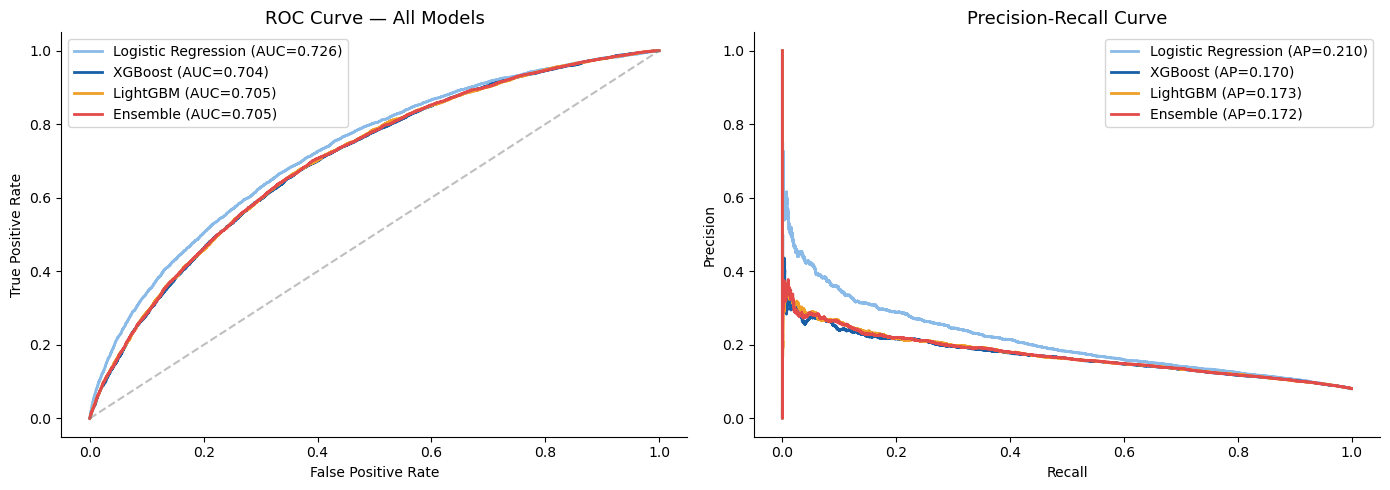

Saved → reports/08_roc_pr_curves.png  ← ADD TO README


In [8]:
# Soft voting ensemble — average probabilities
ensemble_proba = (xgb_proba * 0.5 + lgb_proba * 0.5)
ensemble_pred  = (ensemble_proba >= 0.5).astype(int)

print("ENSEMBLE (XGB 50% + LGB 50%):")
print("=" * 45)
print(f"  ROC-AUC  : {roc_auc_score(y_test, ensemble_proba):.4f}")
print(f"  F1 Score : {f1_score(y_test, ensemble_pred):.4f}")
print(f"  Recall   : {recall_score(y_test, ensemble_pred):.4f}")
print(f"  Precision: {precision_score(y_test, ensemble_pred):.4f}")
print("=" * 45)

# ── ROC Curve ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = {
    'Logistic Regression': lr_proba,
    'XGBoost':             xgb_proba,
    'LightGBM':            lgb_proba,
    'Ensemble':            ensemble_proba
}
colors = ['#8ABBE8', '#185FA5', '#EF9F27', '#E24B4A']

for (name, proba), color in zip(models.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})',
                 color=color, linewidth=2)
axes[0].plot([0,1],[0,1],'--',color='gray',alpha=0.5)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve — All Models', fontsize=13)
axes[0].legend(fontsize=10)

# Precision-Recall Curve
for (name, proba), color in zip(models.items(), colors):
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    axes[1].plot(rec, prec, label=f'{name} (AP={ap:.3f})',
                 color=color, linewidth=2)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve', fontsize=13)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig('../reports/08_roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → reports/08_roc_pr_curves.png  ← ADD TO README")

Best threshold by BUSINESS COST: 0.2
  → Recall=0.621  F1=0.237  Cost=₹183,825,000

Best threshold by F1 SCORE:       0.31
  → Recall=0.408  F1=0.249  Cost=₹193,445,000


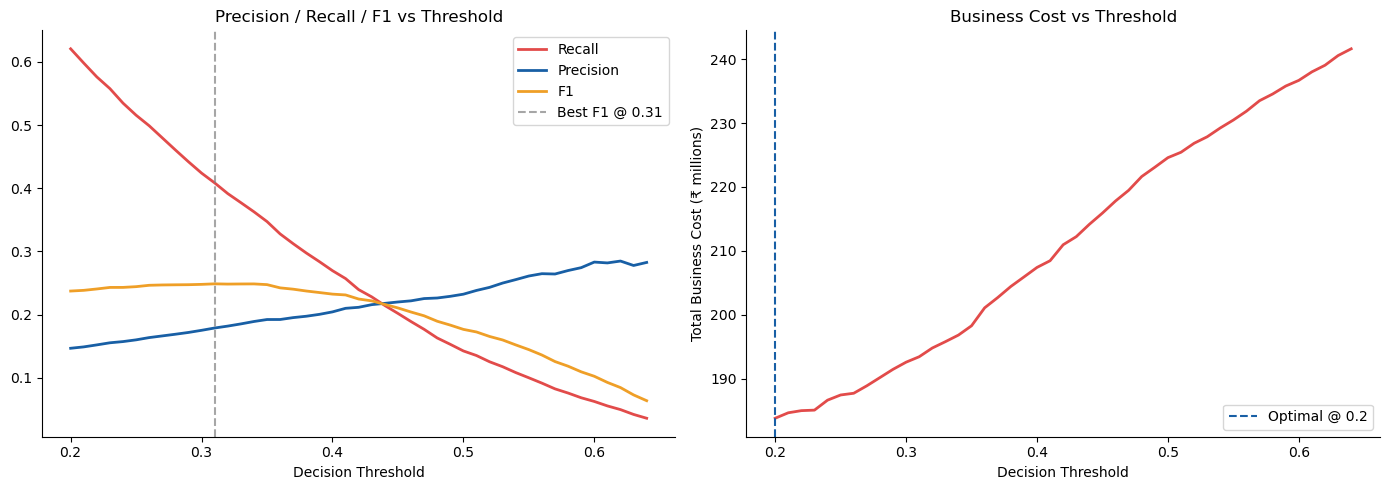

In [9]:
# Business cost assumption:
#   FN (miss a defaulter) costs ₹50,000  — loan loss
#   FP (reject good customer) costs ₹5,000 — lost revenue
COST_FN = 50000
COST_FP = 5000

thresholds = np.arange(0.20, 0.65, 0.01)
results = []

for t in thresholds:
    pred_t = (ensemble_proba >= t).astype(int)
    cm = confusion_matrix(y_test, pred_t)
    tn, fp, fn, tp = cm.ravel()

    total_cost = (fn * COST_FN) + (fp * COST_FP)
    results.append({
        'threshold': round(t, 2),
        'recall':    recall_score(y_test, pred_t),
        'precision': precision_score(y_test, pred_t),
        'f1':        f1_score(y_test, pred_t),
        'total_cost': total_cost,
        'fn': fn, 'fp': fp
    })

results_df = pd.DataFrame(results)
best_cost_row = results_df.loc[results_df['total_cost'].idxmin()]
best_f1_row   = results_df.loc[results_df['f1'].idxmax()]

print(f"Best threshold by BUSINESS COST: {best_cost_row['threshold']}")
print(f"  → Recall={best_cost_row['recall']:.3f}  F1={best_cost_row['f1']:.3f}  Cost=₹{best_cost_row['total_cost']:,.0f}")
print(f"\nBest threshold by F1 SCORE:       {best_f1_row['threshold']}")
print(f"  → Recall={best_f1_row['recall']:.3f}  F1={best_f1_row['f1']:.3f}  Cost=₹{best_f1_row['total_cost']:,.0f}")

# Plot threshold curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(results_df['threshold'], results_df['recall'],
             label='Recall', color='#E24B4A', linewidth=2)
axes[0].plot(results_df['threshold'], results_df['precision'],
             label='Precision', color='#185FA5', linewidth=2)
axes[0].plot(results_df['threshold'], results_df['f1'],
             label='F1', color='#EF9F27', linewidth=2)
axes[0].axvline(best_f1_row['threshold'], color='gray',
                linestyle='--', alpha=0.7, label=f"Best F1 @ {best_f1_row['threshold']}")
axes[0].set_xlabel('Decision Threshold')
axes[0].set_title('Precision / Recall / F1 vs Threshold', fontsize=12)
axes[0].legend(fontsize=10)

axes[1].plot(results_df['threshold'], results_df['total_cost'] / 1e6,
             color='#E24B4A', linewidth=2)
axes[1].axvline(best_cost_row['threshold'], color='#185FA5',
                linestyle='--', label=f"Optimal @ {best_cost_row['threshold']}")
axes[1].set_xlabel('Decision Threshold')
axes[1].set_ylabel('Total Business Cost (₹ millions)')
axes[1].set_title('Business Cost vs Threshold', fontsize=12)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig('../reports/09_threshold_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

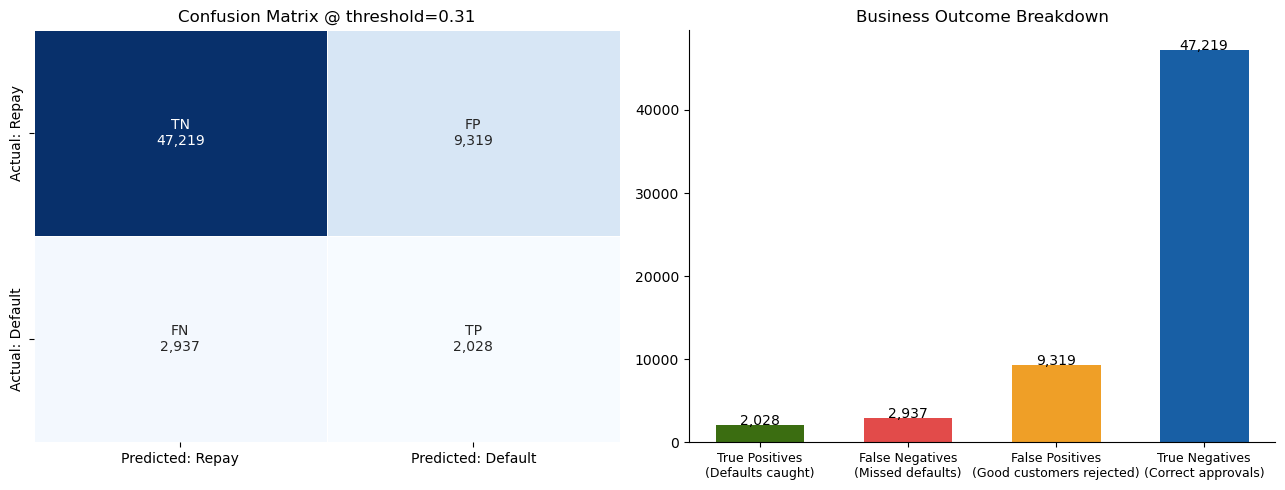


FINAL MODEL REPORT @ threshold = 0.31
              precision    recall  f1-score   support

      Repaid       0.94      0.84      0.89     56538
   Defaulted       0.18      0.41      0.25      4965

    accuracy                           0.80     61503
   macro avg       0.56      0.62      0.57     61503
weighted avg       0.88      0.80      0.83     61503



In [10]:
BEST_THRESHOLD = best_f1_row['threshold']
final_pred = (ensemble_proba >= BEST_THRESHOLD).astype(int)

cm = confusion_matrix(y_test, final_pred)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion matrix heatmap
cm_labels = np.array([[f'TN\n{tn:,}', f'FP\n{fp:,}'],
                       [f'FN\n{fn:,}', f'TP\n{tp:,}']])
sns.heatmap(cm, annot=cm_labels, fmt='', cmap='Blues',
            xticklabels=['Predicted: Repay','Predicted: Default'],
            yticklabels=['Actual: Repay','Actual: Default'],
            ax=axes[0], cbar=False, linewidths=0.5)
axes[0].set_title(f'Confusion Matrix @ threshold={BEST_THRESHOLD}', fontsize=12)

# Business interpretation bar chart
business_data = {
    'True Positives\n(Defaults caught)': tp,
    'False Negatives\n(Missed defaults)': fn,
    'False Positives\n(Good customers rejected)': fp,
    'True Negatives\n(Correct approvals)': tn
}
bar_colors = ['#3B6D11', '#E24B4A', '#EF9F27', '#185FA5']
axes[1].bar(range(4), list(business_data.values()),
            color=bar_colors, edgecolor='none', width=0.6)
axes[1].set_xticks(range(4))
axes[1].set_xticklabels(list(business_data.keys()), fontsize=9)
axes[1].set_title('Business Outcome Breakdown', fontsize=12)
for i, v in enumerate(business_data.values()):
    axes[1].text(i, v + 20, f'{v:,}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('../reports/10_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nFINAL MODEL REPORT @ threshold = {BEST_THRESHOLD}")
print("=" * 50)
print(classification_report(y_test, final_pred,
      target_names=['Repaid','Defaulted']))

In [11]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'XGBoost', 'LightGBM', 'Ensemble'],
    'ROC-AUC':   [
        roc_auc_score(y_test, lr_proba),
        roc_auc_score(y_test, xgb_proba),
        roc_auc_score(y_test, lgb_proba),
        roc_auc_score(y_test, ensemble_proba)
    ],
    'F1':        [
        f1_score(y_test, lr_pred),
        f1_score(y_test, xgb_pred),
        f1_score(y_test, lgb_pred),
        f1_score(y_test, final_pred)
    ],
    'Recall':    [
        recall_score(y_test, lr_pred),
        recall_score(y_test, xgb_pred),
        recall_score(y_test, lgb_pred),
        recall_score(y_test, final_pred)
    ],
    'Precision': [
        precision_score(y_test, lr_pred),
        precision_score(y_test, xgb_pred),
        precision_score(y_test, lgb_pred),
        precision_score(y_test, final_pred)
    ]
}).round(4)

comparison['Best'] = ['', '', '', '← USE THIS']
print(comparison.to_string(index=False))

# Save comparison
comparison.to_csv('../reports/model_comparison.csv', index=False)
print("\nSaved → reports/model_comparison.csv")

              Model  ROC-AUC     F1  Recall  Precision       Best
Logistic Regression   0.7262 0.2473  0.6387     0.1533           
            XGBoost   0.7035 0.1865  0.1605     0.2226           
           LightGBM   0.7051 0.1700  0.1307     0.2432           
           Ensemble   0.7051 0.2487  0.4085     0.1787 ← USE THIS

Saved → reports/model_comparison.csv


In [12]:
import pickle, os

os.makedirs('../models', exist_ok=True)

with open('../models/xgb_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

with open('../models/lgb_model.pkl', 'wb') as f:
    pickle.dump(lgb_model, f)

# Save test data for SHAP notebook
X_test.to_csv('../data/X_test.csv', index=False)
y_test.to_csv('../data/y_test.csv', index=False)

np.save('../data/ensemble_proba.npy', ensemble_proba)

print("Models saved:")
print("  → models/xgb_model.pkl")
print("  → models/lgb_model.pkl")
print("  → data/X_test.csv")
print("  → data/ensemble_proba.npy")
print(f"\nBest threshold: {BEST_THRESHOLD}  ← note this down")

Models saved:
  → models/xgb_model.pkl
  → models/lgb_model.pkl
  → data/X_test.csv
  → data/ensemble_proba.npy

Best threshold: 0.31  ← note this down


In [13]:
best = comparison[comparison['Model']=='Ensemble'].iloc[0]
print(f"""
╔═══════════════════════════════════════════════════════════╗
║           MODELING SUMMARY                                ║
╠═══════════════════════════════════════════════════════════╣
║                                                           ║
║  MODELS TRAINED                                           ║
║  1. Logistic Regression (baseline)                        ║
║  2. XGBoost (300 trees, depth=5, SMOTE)                   ║
║  3. LightGBM (300 trees, 31 leaves, SMOTE)                ║
║  4. Soft-voting Ensemble (50/50)  ← FINAL MODEL           ║
║                                                           ║
║  IMBALANCE HANDLING                                       ║
║  → SMOTE applied post-split (no leakage)                  ║
║  → scale_pos_weight used in XGBoost                       ║
║                                                           ║
║  FINAL ENSEMBLE RESULTS                                   ║
║  → ROC-AUC   : {best['ROC-AUC']:.4f}                              ║
║  → F1 Score  : {best['F1']:.4f}                              ║
║  → Recall    : {best['Recall']:.4f}                              ║
║  → Precision : {best['Precision']:.4f}                              ║
║  → Threshold : {BEST_THRESHOLD}                                  ║
║                                                           ║
║  NEXT STEP: SHAP Explainability — 04_explainability.ipynb ║
╚═══════════════════════════════════════════════════════════╝
""")


╔═══════════════════════════════════════════════════════════╗
║           MODELING SUMMARY                                ║
╠═══════════════════════════════════════════════════════════╣
║                                                           ║
║  MODELS TRAINED                                           ║
║  1. Logistic Regression (baseline)                        ║
║  2. XGBoost (300 trees, depth=5, SMOTE)                   ║
║  3. LightGBM (300 trees, 31 leaves, SMOTE)                ║
║  4. Soft-voting Ensemble (50/50)  ← FINAL MODEL           ║
║                                                           ║
║  IMBALANCE HANDLING                                       ║
║  → SMOTE applied post-split (no leakage)                  ║
║  → scale_pos_weight used in XGBoost                       ║
║                                                           ║
║  FINAL ENSEMBLE RESULTS                                   ║
║  → ROC-AUC   : 0.7051                              ║
║  → F1 Score 